# 11 - ResNet50 con transfer learning usando arrays

Usa ResNet50 preentrenada en ImageNet y fine-tuning parcial. Se diferencia del `09_resnet_scratch` porque parte de pesos preentrenados, normalmente mucho mas eficaces con datasets medianos.


## Librerias y configuracion


In [1]:
import json
import time
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

RUN_START = time.perf_counter()

print('GPUs disponibles:', tf.config.list_physical_devices('GPU'))


2026-06-03 10:43:52.352440: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780483432.554168      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780483432.621389      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780483433.159924      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780483433.159971      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780483433.159974      58 computation_placer.cc:177] computation placer alr

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
SEED = 42
BATCH_SIZE = 32
EPOCHS_STAGE1 = 15
EPOCHS_STAGE2 = 20
VALIDATION_SIZE = 0.15
IMAGE_SHAPE = (224, 224, 3)

np.random.seed(SEED)
tf.random.set_seed(SEED)


## Datos


### Localizacion de inputs


In [3]:
KAGGLE_INPUT_DIR = Path('/kaggle/input')
WORKDIR = Path('/kaggle/working')

if not KAGGLE_INPUT_DIR.exists():
    raise FileNotFoundError('No existe /kaggle/input. Ejecuta este notebook en Kaggle.')

array_matches = sorted(KAGGLE_INPUT_DIR.rglob('X_all.npy'))
working_candidate = WORKDIR / 'xview_arrays' / 'X_all.npy'
if working_candidate.exists():
    array_matches = [working_candidate] + array_matches

if not array_matches:
    available_inputs = [p.name for p in KAGGLE_INPUT_DIR.iterdir() if p.is_dir()]
    raise FileNotFoundError(
        'No se encontro X_all.npy. Anade el dataset xview_arrays creado con 00_1. '
        f'Inputs disponibles: {available_inputs}'
    )

ARRAYS_ROOT = array_matches[0].parent

json_matches = sorted(KAGGLE_INPUT_DIR.rglob('xview_ann_train.json'))
if not json_matches:
    available_inputs = [p.name for p in KAGGLE_INPUT_DIR.iterdir() if p.is_dir()]
    raise FileNotFoundError(
        'No se encontro xview_ann_train.json. Anade tambien el dataset original xview_recognition. '
        f'Inputs disponibles: {available_inputs}'
    )

ANN_JSON = json_matches[0]
DATA_ROOT = ANN_JSON.parent
TRAIN_DIR = DATA_ROOT / 'xview_train'
TEST_DIR = DATA_ROOT / 'xview_test'

print('ARRAYS_ROOT:', ARRAYS_ROOT)
print('DATA_ROOT:', DATA_ROOT)
print('ANN_JSON:', ANN_JSON)
print('TRAIN_DIR exists:', TRAIN_DIR.exists())
print('TEST_DIR exists:', TEST_DIR.exists())


ARRAYS_ROOT: /kaggle/input/datasets/eccvdl/xview-arrays/xview_arrays
DATA_ROOT: /kaggle/input/datasets/eccvdl/xview-recognition
ANN_JSON: /kaggle/input/datasets/eccvdl/xview-recognition/xview_ann_train.json
TRAIN_DIR exists: True
TEST_DIR exists: True


### Lectura de arrays


In [4]:
DATA_LOAD_START = time.perf_counter()

X_all = np.load(ARRAYS_ROOT / 'X_all.npy')
y_all_idx = np.load(ARRAYS_ROOT / 'y_all_idx.npy')
filenames = np.load(ARRAYS_ROOT / 'filenames.npy')
image_ids = np.load(ARRAYS_ROOT / 'image_ids.npy')
category_names = np.load(ARRAYS_ROOT / 'category_names.npy').astype(str).tolist()
num_classes = len(category_names)

print('X_all:', X_all.shape, X_all.dtype, 'RAM aprox:', X_all.nbytes / 1024**3, 'GB')
print('y_all_idx:', y_all_idx.shape, y_all_idx.dtype)
print('filenames:', filenames.shape)
print('image_ids:', image_ids.shape)
print('num_classes:', num_classes)
print(category_names)


X_all: (18746, 224, 224, 3) uint8 RAM aprox: 2.6280040740966797 GB
y_all_idx: (18746,) int32
filenames: (18746,)
image_ids: (18746,)
num_classes: 13
['Cargo plane', 'Small car', 'Bus', 'Truck', 'Motorboat', 'Fishing vessel', 'Dump truck', 'Excavator', 'Building', 'Helipad', 'Storage tank', 'Shipping container', 'Pylon']


### Comprobacion de una imagen


Filename: xview_train/Building/0234476c-a017-4c9b-bd2f-872193076cca.tif
Image id: 0234476c-a017-4c9b-bd2f-872193076cca.tif
Shape: (224, 224, 3)
Dtype: uint8
Min / Max: 0 86
Etiqueta: Building
Primeros pixeles del array original:
[[[45 30 19]
  [45 30 19]
  [46 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]]


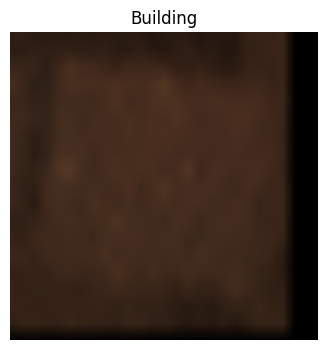

In [5]:
sample_idx = 0
sample_img = X_all[sample_idx]
sample_label_idx = int(y_all_idx[sample_idx])

print('Filename:', filenames[sample_idx])
print('Image id:', image_ids[sample_idx])
print('Shape:', sample_img.shape)
print('Dtype:', sample_img.dtype)
print('Min / Max:', sample_img.min(), sample_img.max())
print('Etiqueta:', category_names[sample_label_idx])
print('Primeros pixeles del array original:')
print(sample_img[:3, :3, :])

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.title(category_names[sample_label_idx])
plt.axis('off')
plt.show()


### Split train/valid


In [6]:
indices = np.arange(len(X_all))
train_idx, val_idx = train_test_split(
    indices,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    shuffle=True,
    stratify=y_all_idx,
)

X_train = X_all[train_idx]
X_valid = X_all[val_idx]
y_train_idx = y_all_idx[train_idx]
y_valid_idx = y_all_idx[val_idx]

y_train = tf.keras.utils.to_categorical(y_train_idx, num_classes=num_classes).astype(np.float32)
y_valid = tf.keras.utils.to_categorical(y_valid_idx, num_classes=num_classes).astype(np.float32)

DATA_LOAD_TIME = time.perf_counter() - DATA_LOAD_START

print('X_train:', X_train.shape, X_train.dtype, 'RAM aprox:', X_train.nbytes / 1024**3, 'GB')
print('X_valid:', X_valid.shape, X_valid.dtype, 'RAM aprox:', X_valid.nbytes / 1024**3, 'GB')
print('y_train:', y_train.shape, y_train.dtype)
print('y_valid:', y_valid.shape, y_valid.dtype)
print(f'Tiempo carga arrays/split: {DATA_LOAD_TIME:.2f} s')


X_train: (15934, 224, 224, 3) uint8 RAM aprox: 2.2337894439697266 GB
X_valid: (2812, 224, 224, 3) uint8 RAM aprox: 0.3942146301269531 GB
y_train: (15934, 13) float32
y_valid: (2812, 13) float32
Tiempo carga arrays/split: 15.61 s


## Red


### ResNet50 preentrenada


In [7]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

inputs = tf.keras.Input(shape=IMAGE_SHAPE)
x = tf.keras.layers.Lambda(resnet_preprocess, name='resnet50_preprocess')(inputs)

base = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_tensor=x,
)

base.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='resnet50_transfer')

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()


I0000 00:00:1780483479.884913      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780483479.891147      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50_preprocess │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ resnet50_preproc… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c

 Total params: 23,614,349 (90.08 MB)

 Trainable params: 26,637 (104.05 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Funcion de graficas


In [8]:
def plot_history(history, title):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='valid')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='valid')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()


### Callbacks


In [9]:
def make_callbacks(model_path, patience=6):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            str(model_path),
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
        tf.keras.callbacks.TerminateOnNaN(),
    ]


In [10]:
MODEL_PATH_STAGE1 = WORKDIR / '11_resnet_transfer_stage1.weights.h5'
callbacks_stage1 = make_callbacks(MODEL_PATH_STAGE1, patience=6)
print('Modelo stage 1:', MODEL_PATH_STAGE1)


Modelo stage 1: /kaggle/working/11_resnet_transfer_stage1.weights.h5


### Entrenamiento stage 1


In [11]:
STAGE1_START = time.perf_counter()

history_stage1 = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks_stage1,
    verbose=1,
)

STAGE1_TIME = time.perf_counter() - STAGE1_START

best_idx_stage1 = int(np.argmax(history_stage1.history['val_accuracy']))
best_value_stage1 = float(np.max(history_stage1.history['val_accuracy']))
print('Best stage 1 model: epoch', best_idx_stage1 + 1, '- val_accuracy', best_value_stage1)
print(f'Tiempo stage 1: {STAGE1_TIME:.2f} s')


Epoch 1/15


I0000 00:00:1780483495.685854     128 service.cc:152] XLA service 0x78765c08d5f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780483495.685910     128 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780483495.685917     128 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780483497.711073     128 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/498 ━━━━━━━━━━━━━━━━━━━━ 1:59:13 14s/step - accuracy: 0.1250 - loss: 3.3884

I0000 00:00:1780483503.026578     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


498/498 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5322 - loss: 1.4716
Epoch 1: val_accuracy improved from None to 0.69559, saving model to /kaggle/working/11_resnet_transfer_stage1.weights.h5

Epoch 1: finished saving model to /kaggle/working/11_resnet_transfer_stage1.weights.h5
498/498 ━━━━━━━━━━━━━━━━━━━━ 76s 124ms/step - accuracy: 0.6170 - loss: 1.1827 - val_accuracy: 0.6956 - val_loss: 0.9316 - learning_rate: 0.0010
Epoch 2/15
498/498 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6932 - loss: 0.9217
Epoch 2: val_accuracy improved from 0.69559 to 0.70092, saving model to /kaggle/working/11_resnet_transfer_stage1.weights.h5

Epoch 2: finished saving model to /kaggle/working/11_resnet_transfer_stage1.weights.h5
498/498 ━━━━━━━━━━━━━━━━━━━━ 51s 102ms/step - accuracy: 0.6962 - loss: 0.9122 - val_accuracy: 0.7009 - val_loss: 0.9360 - learning_rate: 0.0010
Epoch 3/15
498/498 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.7191 - loss: 0.8517
Epoch 3: val_accuracy improved from 0.7

### Graficas stage 1


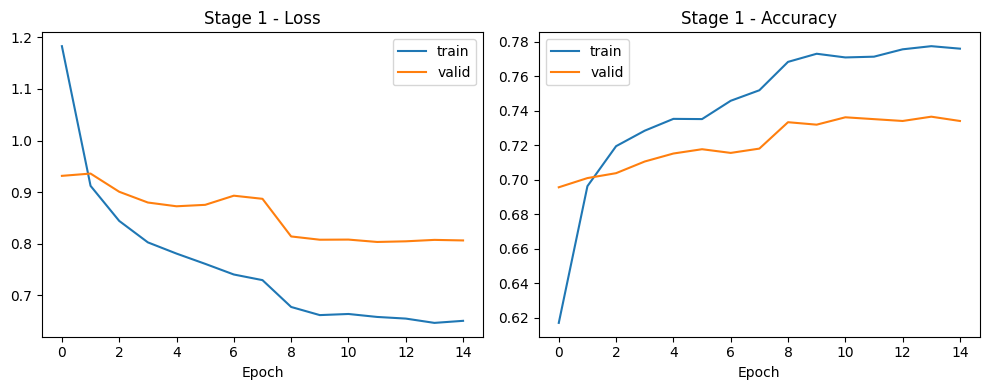

In [12]:
plot_history(history_stage1, 'Stage 1')


### Fine-tuning stage 2


In [13]:
base.trainable = True
for layer in base.layers[:-40]:
    layer.trainable = False
for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

MODEL_PATH = WORKDIR / '11_resnet_transfer_finetuned.weights.h5'
callbacks_stage2 = make_callbacks(MODEL_PATH, patience=6)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

STAGE2_START = time.perf_counter()

history_stage2 = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks_stage2,
    verbose=1,
)

STAGE2_TIME = time.perf_counter() - STAGE2_START

best_idx_stage2 = int(np.argmax(history_stage2.history['val_accuracy']))
best_value_stage2 = float(np.max(history_stage2.history['val_accuracy']))
print('Best stage 2 model: epoch', best_idx_stage2 + 1, '- val_accuracy', best_value_stage2)
print(f'Tiempo stage 2: {STAGE2_TIME:.2f} s')
print('Modelo final:', MODEL_PATH)


Epoch 1/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.7806 - loss: 0.6437
Epoch 1: val_accuracy improved from None to 0.75462, saving model to /kaggle/working/11_resnet_transfer_finetuned.weights.h5

Epoch 1: finished saving model to /kaggle/working/11_resnet_transfer_finetuned.weights.h5
498/498 ━━━━━━━━━━━━━━━━━━━━ 110s 185ms/step - accuracy: 0.7770 - loss: 0.6431 - val_accuracy: 0.7546 - val_loss: 0.7581 - learning_rate: 1.0000e-05
Epoch 2/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.8215 - loss: 0.5162
Epoch 2: val_accuracy improved from 0.75462 to 0.75640, saving model to /kaggle/working/11_resnet_transfer_finetuned.weights.h5

Epoch 2: finished saving model to /kaggle/working/11_resnet_transfer_finetuned.weights.h5
498/498 ━━━━━━━━━━━━━━━━━━━━ 77s 154ms/step - accuracy: 0.8194 - loss: 0.5184 - val_accuracy: 0.7564 - val_loss: 0.7584 - learning_rate: 1.0000e-05
Epoch 3/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.8510 - loss: 0.4293
Epoc

### Graficas stage 2


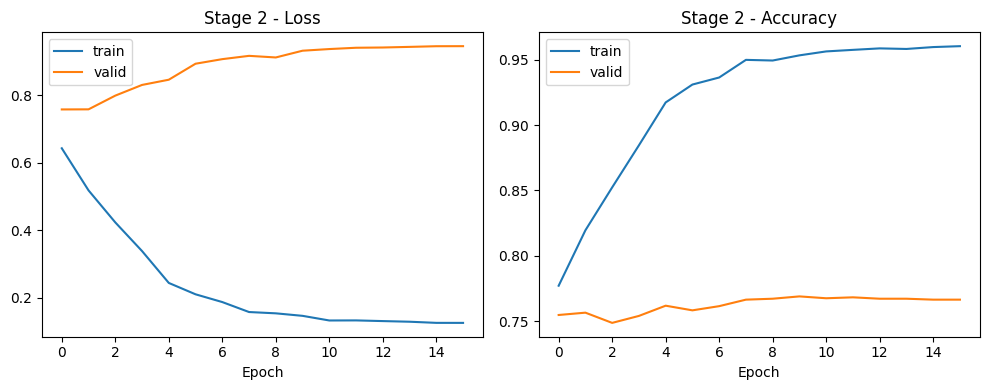

In [14]:
plot_history(history_stage2, 'Stage 2')


## Resultados


### Predicciones de validacion


In [15]:
model.load_weights(MODEL_PATH)

valid_loss, valid_accuracy = model.evaluate(X_valid, y_valid, batch_size=BATCH_SIZE, verbose=1)
print('Validation loss:', valid_loss)
print('Validation accuracy:', valid_accuracy)

probs = model.predict(X_valid, batch_size=BATCH_SIZE, verbose=1)
y_pred_idx = np.argmax(probs, axis=1)
y_true_idx = y_valid_idx


88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.7688 - loss: 0.9320
Validation loss: 0.9319581985473633
Validation accuracy: 0.7688478231430054
88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 131ms/step


### Matriz de confusion


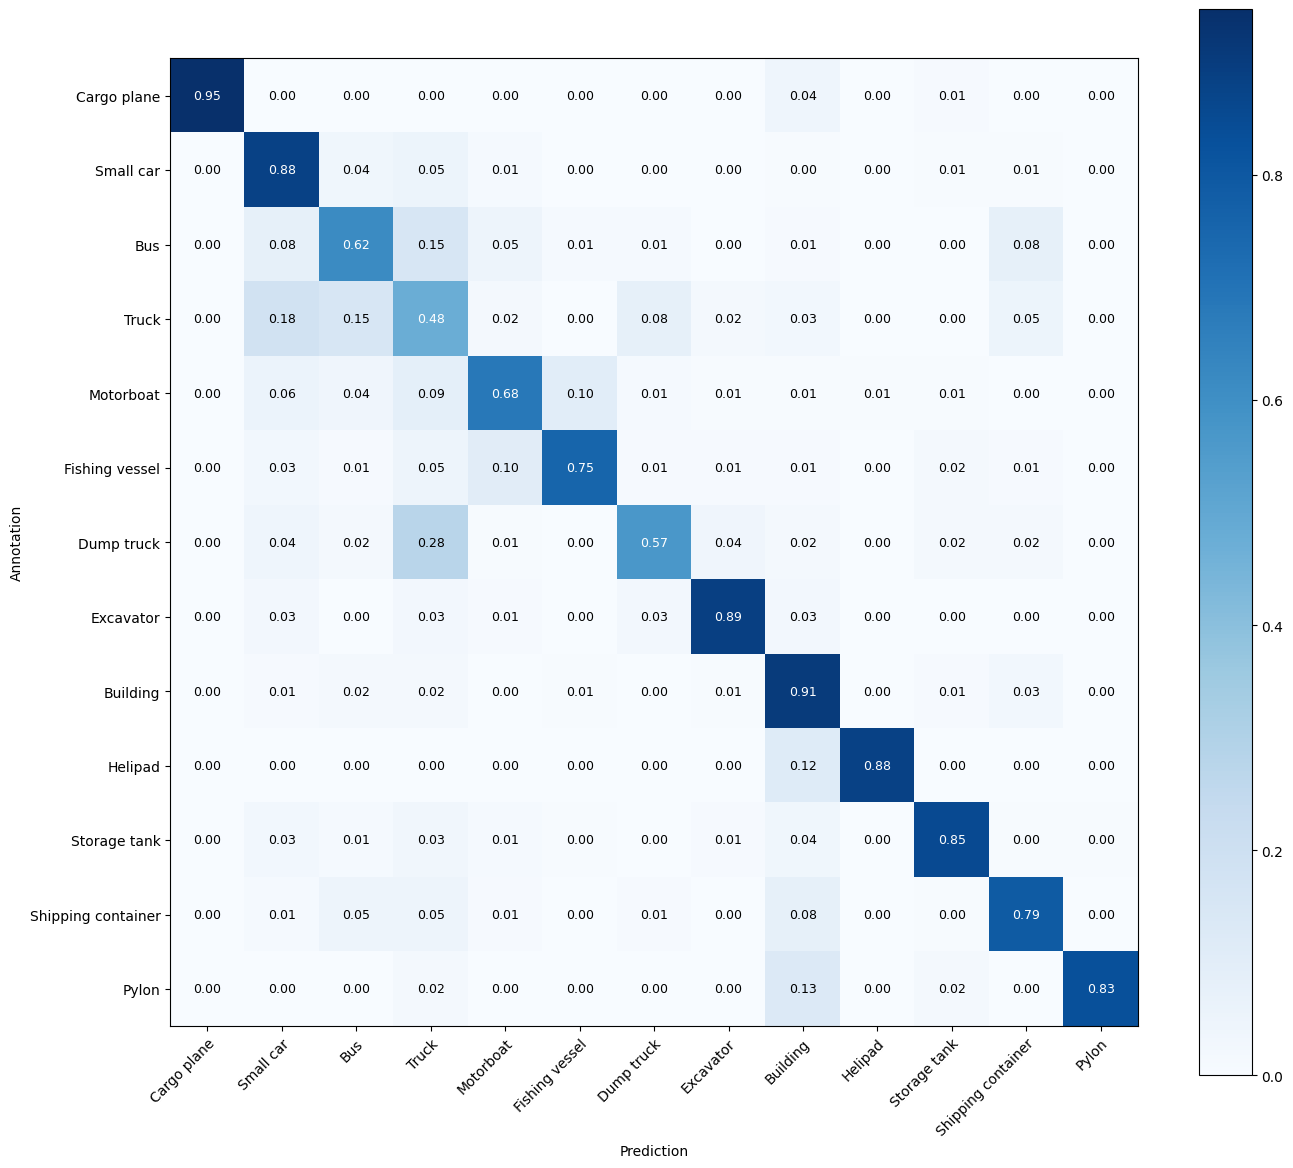

In [16]:
cm = confusion_matrix(y_true_idx, y_pred_idx, labels=list(range(num_classes)))

def draw_confusion_matrix_percent(cm, labels):
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), np.finfo(np.float64).eps)

    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.colormaps['Blues'], vmin=0.0, vmax=max(0.01, cm_norm.max()))
    fig.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        ylabel='Annotation',
        xlabel='Prediction',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    threshold = cm_norm.max() / 2.0
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            value = cm_norm[i, j]
            ax.text(
                j,
                i,
                f'{value:.2f}',
                ha='center',
                va='center',
                color='white' if value > threshold else 'black',
                fontsize=9,
            )

    fig.tight_layout()
    plt.show()
    return cm_norm

cm_norm = draw_confusion_matrix_percent(cm, category_names)


### Metricas


In [17]:
print(classification_report(y_true_idx, y_pred_idx, target_names=category_names, digits=4))


                    precision    recall  f1-score   support

       Cargo plane     0.9890    0.9474    0.9677        95
         Small car     0.7917    0.8838    0.8352       499
               Bus     0.6174    0.6151    0.6163       265
             Truck     0.4847    0.4759    0.4802       332
         Motorboat     0.7267    0.6813    0.7032       160
    Fishing vessel     0.7767    0.7547    0.7656       106
        Dump truck     0.7343    0.5676    0.6402       185
         Excavator     0.8333    0.8898    0.8607       118
          Building     0.8921    0.9054    0.8987       539
           Helipad     0.8824    0.8824    0.8824        17
      Storage tank     0.9126    0.8545    0.8826       220
Shipping container     0.7479    0.7904    0.7686       229
             Pylon     0.9750    0.8298    0.8966        47

          accuracy                         0.7688      2812
         macro avg     0.7972    0.7752    0.7845      2812
      weighted avg     0.7682    0.768

## Codabench


### Generacion del submission


In [18]:
CODABENCH_START = time.perf_counter()

def load_test_image(filename):
    return np.array(Image.open(DATA_ROOT / filename).convert('RGB'))

test_files = sorted(TEST_DIR.rglob('*.tif'))
print('Number of testing images:', len(test_files))
assert len(test_files) > 0, 'No se encontraron imagenes .tif en TEST_DIR.'

model.load_weights(MODEL_PATH)
predictions_data = {'images': {}, 'annotations': {}}
batch_size = 64

for start in range(0, len(test_files), batch_size):
    batch_paths = test_files[start:start + batch_size]
    json_filenames = [path.relative_to(TEST_DIR).as_posix() for path in batch_paths]
    load_filenames = [path.relative_to(DATA_ROOT).as_posix() for path in batch_paths]

    images = np.stack([load_test_image(filename) for filename in load_filenames]).astype(np.uint8)
    probs = model.predict(images, batch_size=batch_size, verbose=0)
    pred_idx = np.argmax(probs, axis=1)
    pred_scores = np.max(probs, axis=1)

    for offset, (path, json_filename, cls_idx, score) in enumerate(zip(batch_paths, json_filenames, pred_idx, pred_scores)):
        idx = start + offset
        predictions_data['images'][idx] = {
            'image_id': path.name,
            'filename': json_filename,
            'width': 224,
            'height': 224,
        }
        predictions_data['annotations'][idx] = {
            'image_id': path.name,
            'category_id': category_names[int(cls_idx)],
            'score': float(score),
            'bbox': [0, 0, 224, 224],
        }

    print(f'Procesadas {min(start + batch_size, len(test_files))}/{len(test_files)}')

assert len(predictions_data['images']) == len(test_files)
assert len(predictions_data['annotations']) == len(test_files)

prediction_path = WORKDIR / 'prediction_11.json'
submission_path = WORKDIR / 'submission_11.zip'

with open(prediction_path, 'w', encoding='utf-8') as outfile:
    json.dump(predictions_data, outfile)

with zipfile.ZipFile(submission_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(prediction_path, arcname='prediction.json')

CODABENCH_TIME = time.perf_counter() - CODABENCH_START

print('Archivos generados:')
print(prediction_path, '-', prediction_path.stat().st_size, 'bytes')
print(submission_path, '-', submission_path.stat().st_size, 'bytes')
print(f'Tiempo Codabench: {CODABENCH_TIME:.2f} s')

from IPython.display import FileLink, display
display(FileLink(str(submission_path)))


Number of testing images: 2365
Procesadas 64/2365
Procesadas 128/2365
Procesadas 192/2365
Procesadas 256/2365
Procesadas 320/2365
Procesadas 384/2365
Procesadas 448/2365
Procesadas 512/2365
Procesadas 576/2365
Procesadas 640/2365
Procesadas 704/2365
Procesadas 768/2365
Procesadas 832/2365
Procesadas 896/2365
Procesadas 960/2365
Procesadas 1024/2365
Procesadas 1088/2365
Procesadas 1152/2365
Procesadas 1216/2365
Procesadas 1280/2365
Procesadas 1344/2365
Procesadas 1408/2365
Procesadas 1472/2365
Procesadas 1536/2365
Procesadas 1600/2365
Procesadas 1664/2365
Procesadas 1728/2365
Procesadas 1792/2365
Procesadas 1856/2365
Procesadas 1920/2365
Procesadas 1984/2365
Procesadas 2048/2365
Procesadas 2112/2365
Procesadas 2176/2365
Procesadas 2240/2365
Procesadas 2304/2365
Procesadas 2365/2365
Archivos generados:
/kaggle/working/prediction_11.json - 725431 bytes
/kaggle/working/submission_11.zip - 160736 bytes
Tiempo Codabench: 43.25 s


/kaggle/working/submission_11.zip

### Resumen de tiempos


In [19]:
TOTAL_TIME = time.perf_counter() - RUN_START
print('Resumen de tiempos')
if 'DATA_LOAD_TIME' in globals():
    print(f'- Carga/preparacion de datos: {DATA_LOAD_TIME:.2f} s')
if 'STAGE1_TIME' in globals():
    print(f'- Stage 1: {STAGE1_TIME:.2f} s')
if 'STAGE2_TIME' in globals():
    print(f'- Stage 2: {STAGE2_TIME:.2f} s')
if 'CODABENCH_TIME' in globals():
    print(f'- Codabench: {CODABENCH_TIME:.2f} s')
print(f'- Tiempo total Run All: {TOTAL_TIME:.2f} s')
print(f'- Tiempo total Run All: {TOTAL_TIME / 60:.2f} min')


Resumen de tiempos
- Carga/preparacion de datos: 15.61 s
- Stage 1: 822.86 s
- Stage 2: 1245.51 s
- Codabench: 43.25 s
- Tiempo total Run All: 2175.60 s
- Tiempo total Run All: 36.26 min
